# 06 · 작물 배분 최적화 — 단작 조합 최적화 (GA)

개요 v3 **§6-(2) 단작 MILP** + **§6-(3) 전환비용** 결합. A→C 전략의 **1단계(GA, 필수분)**.

각 카운티 $c$ 가 작물 하나($k \in \{$옥수수, 대두$\}$)를 골라 농지 전체 $A_c$ 를 배정한다.
+2℃ 온난화 시나리오(05 산출) 하에서 **총생산 − 전환비용**을 최대화한다.

$$\max_{z} \;\; \sum_c \sum_k A_c \cdot v[c,k] \cdot z[c,k] \;-\; \lambda \sum_{c \,:\, z_c \neq \bar{x}_c} A_c
\qquad \text{s.t.} \;\; \sum_k z[c,k] = 1, \;\; z \in \{0,1\}$$

전환비용은 개요 §6 주석(및 Q3 v3 보충)대로 **"현재 작물과 다르게 고른 카운티"** 에 벌점을 주되,
카운티 개수가 아니라 **면적 가중**($A_c$ 합)으로 센다 → $\lambda$ 의 단위가 목적함수와 같아져($/ac$)
"전환을 정당화하려면 에이커당 얼마의 이득이 필요한가"로 직접 해석된다.

**이 노트북의 두 가지 방법론적 결정** (§1-2, §6 에서 근거 제시):
1. $v[c,k]$ 는 **bu/ac 가 아니라 순이익 \$/ac**. 옥수수 부셸과 대두 부셸은 더할 수 없는 단위다.
2. 전환비용만 있는 단작 문제는 **카운티별로 분리(separable)** → 정확 최적해를 즉시 구할 수 있다.
   GA 를 이 정확해와 검증하고(H5), GA 가 **정말 필요해지는 지점**은 카운티를 서로 묶는
   **최소 수요 제약**(§6)이다.

In [1]:
import json, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

warnings.filterwarnings('ignore')

RAW  = Path('..') / 'data' / 'raw'            # 읽기 전용 — 절대 수정 금지
PROC = Path('..') / 'data' / 'processed'
FIG  = Path('..') / 'outputs' / 'figures'
RES  = Path('..') / 'outputs' / 'results'
FIG.mkdir(parents=True, exist_ok=True); RES.mkdir(parents=True, exist_ok=True)

# 05 와 동일한 팔레트 / 스타일
SURFACE, INK, SECOND, MUTED = '#fcfcfb', '#0b0b0b', '#52514e', '#898781'
GRID, AXIS = '#e1e0d9', '#c3c2b7'
BLUE, AQUA, YELLOW, GREEN, VIOLET, RED = '#2a78d6', '#1baf7a', '#eda100', '#008300', '#4a3aa7', '#e34948'
DIVERGING = LinearSegmentedColormap.from_list('rd_gy_bl', [RED, '#f0efec', BLUE])

CORN_C, SOY_C = '#eda100', '#1baf7a'          # 옥수수 = 노랑, 대두 = 초록
CROPS = ['corn', 'soybean']
CROP_KO = {'corn': '옥수수', 'soybean': '대두'}

mpl.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150,
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': AXIS, 'axes.labelcolor': SECOND, 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Malgun Gothic', 'Segoe UI', 'DejaVu Sans'],
    'axes.unicode_minus': False,
    'axes.titlesize': 12.5, 'axes.titleweight': 'semibold',
    'axes.labelsize': 10.5, 'lines.linewidth': 2,
})

def save(fig, name):
    p = FIG / name
    fig.savefig(p, bbox_inches='tight')
    print('saved:', p)

SEED = 42                      # 재현성
rng_global = np.random.default_rng(SEED)

# ── 경제 파라미터 (§1-2 에서 근거) ─────────────────────────────────────────
# 가격: 최근 시즌 평균 농가 판매가 수준
# 변동비: USDA ERS Commodity Costs & Returns 의 operating cost 수준
#         (종자·비료·농약·연료. 토지임차료/감가상각 같은 고정비는 제외 — 작물 선택과 무관)
PRICE = {'corn': 4.50,  'soybean': 10.50}     # $/bu
OPCOST = {'corn': 400.0, 'soybean': 205.0}    # $/ac
# 옥수수 변동비가 대두의 약 2배인 이유: 옥수수는 질소비료를 많이 쓰고 대두는 질소고정을 한다.
# 이 비대칭이 "대두가 왜 재배되는가"의 경제적 실체다.

DELTA_T    = 2.0
BASE, WARM = 'baseline', 'plus2C'
YEAR_FIXED = 2015              # 트리 모델 외삽 금지

print('가격  $/bu :', PRICE)
print('변동비 $/ac:', OPCOST)
print('seed =', SEED)

가격  $/bu : {'corn': 4.5, 'soybean': 10.5}
변동비 $/ac: {'corn': 400.0, 'soybean': 205.0}
seed = 42


## 1. 입력 로드 · 공통 카운티

### 1-1. 04b 에서 확정된 주의사항 반영
1. **공통 카운티에서만 최적화** — 옥수수·대두 둘 다 재배 가능한 카운티만 재배치 선택지가 있다.
2. **시나리오 연도 매핑** — `scenarios.parquet` 은 `year` 가 없고 `year_fixed`(=2015)를 쓴다.
   모델에 넣기 전 `year_fixed → year` 로 매핑해야 예측이 돈다.

In [2]:
# ── 모델 ────────────────────────────────────────────────────────────────────
BUNDLE = {'corn':    joblib.load(PROC / 'yield_model_final.joblib'),
          'soybean': joblib.load(PROC / 'soybean_model_final.joblib')}
for k, b in BUNDLE.items():
    print('%-8s %-9s 전략 %s | CV R2 %.4f | RMSE %.2f | %d feats'
          % (CROP_KO[k], b['model_name'], b['strategy'], b['cv_r2_mean'], b['cv_rmse_mean'], len(b['features'])))

FEATS = BUNDLE['corn']['features']
assert FEATS == BUNDLE['soybean']['features'], '두 모델의 피처셋이 다르다'
print('\n두 모델 피처셋 동일 (%d개) — 같은 X 행렬로 둘 다 예측 가능' % len(FEATS))

# ── 시나리오 (05 산출) ──────────────────────────────────────────────────────
sc = pd.read_parquet(PROC / 'scenarios.parquet')
sc_meta = json.load(open(PROC / 'scenarios_columns.json', encoding='utf-8'))
print('\nscenarios: %s행 · %s' % (len(sc), list(pd.unique(sc.scenario))))
print('  delta_t=%.1f℃ · year_fixed=%d · 평년구간=%s'
      % (sc_meta['delta_t'], sc_meta['year_fixed'], sc_meta['climate_normal_window']))

# ── 공통 카운티 ────────────────────────────────────────────────────────────
corn_ct = set(pd.read_parquet(PROC / 'corn_panel.parquet',    columns=['stco']).stco.unique())
soy_ct  = set(pd.read_parquet(PROC / 'soybean_panel.parquet', columns=['stco']).stco.unique())
COUNTIES = np.array(sorted(corn_ct & soy_ct & set(sc.stco.unique())))
N = len(COUNTIES)
print('\n옥수수 패널 %d · 대두 패널 %d · 시나리오 %d' % (len(corn_ct), len(soy_ct), sc.stco.nunique()))
print('→ 공통 카운티 N = %d  (재배치 선택지가 있는 카운티만)' % N)
assert N == 2142, N

# ── A_c (농지 규모, gridInfo numAg2011) ────────────────────────────────────
A = (sc.drop_duplicates('stco').set_index('stco')['A_c'].reindex(COUNTIES).to_numpy(float))
assert np.isfinite(A).all() and (A > 0).all()
A_TOT = A.sum()
print('\nA_c: 총 %.3e ac · 중앙값 %.0f ac · [%.0f, %.0f]' % (A_TOT, np.median(A), A.min(), A.max()))

옥수수      LightGBM  전략 B | CV R2 0.7318 | RMSE 20.08 | 97 feats
대두       LightGBM  전략 B | CV R2 0.8069 | RMSE 4.62 | 97 feats

두 모델 피처셋 동일 (97개) — 같은 X 행렬로 둘 다 예측 가능



scenarios: 5288행 · ['baseline', 'plus2C']
  delta_t=2.0℃ · year_fixed=2015 · 평년구간=[2006, 2015]

옥수수 패널 2644 · 대두 패널 2169 · 시나리오 2644
→ 공통 카운티 N = 2142  (재배치 선택지가 있는 카운티만)

A_c: 총 1.583e+09 ac · 중앙값 598682 ac · [8316, 4573893]


## 2. 예측 수확량 행렬 `y_hat[c, k]`

시나리오별 · 작물별로 2,142 × 2 예측 행렬을 만든다.
온도 피처는 해당 시나리오 값, `year` 는 2015 고정, 옥수수는 옥수수 모델 · 대두는 대두 모델.

In [3]:
X_of = {}
y_hat = {}   # y_hat[scenario][crop] -> (N,) bu/ac

for s in [BASE, WARM]:
    d = sc[sc.scenario == s].set_index('stco').reindex(COUNTIES).copy()
    d['year'] = d['year_fixed']                 # ★ 주의사항 2: year_fixed → year
    X = d[FEATS]
    assert X.notna().all().all(), '%s: 피처 결측' % s
    X_of[s] = X
    y_hat[s] = {k: BUNDLE[k]['model'].predict(X) for k in CROPS}

rows = []
for s in [BASE, WARM]:
    for k in CROPS:
        y = y_hat[s][k]
        rows.append(dict(시나리오=s, 작물=CROP_KO[k], 평균=y.mean(), 중앙값=np.median(y),
                         최소=y.min(), 최대=y.max()))
print('예측 수확량 (bu/ac)')
print(pd.DataFrame(rows).to_string(index=False, float_format='%.1f'))

d_corn = y_hat[WARM]['corn']    - y_hat[BASE]['corn']
d_soy  = y_hat[WARM]['soybean'] - y_hat[BASE]['soybean']
print('\n+%.0f℃ 효과 (면적가중)' % DELTA_T)
for k, d0 in [('corn', d_corn), ('soybean', d_soy)]:
    b = np.average(y_hat[BASE][k], weights=A)
    print('  %-4s  %+6.2f bu/ac  (%+.1f%%)' % (CROP_KO[k], np.average(d0, weights=A),
                                               100 * np.average(d0, weights=A) / b))

예측 수확량 (bu/ac)
    시나리오  작물    평균   중앙값   최소    최대
baseline 옥수수 132.5 135.4 51.1 207.2
baseline  대두  39.9  39.5 13.5  64.5
  plus2C 옥수수 119.2 119.7 45.4 181.6
  plus2C  대두  35.7  35.2  7.7  58.4

+2℃ 효과 (면적가중)
  옥수수   -13.02 bu/ac  (-9.5%)
  대두     -4.19 bu/ac  (-10.1%)


### 2-1. ⚠ 목적함수의 단위 문제 — 왜 bu/ac 를 그대로 쓰면 안 되는가

개요 §6-(2) 의 목적함수는 $\sum_c \sum_k y\_hat[c,k] \cdot A_c \cdot z[c,k]$ 로, 작물 간 **부셸을 그냥 더한다.**
그런데 옥수수 1 부셸(56 lb)과 대두 1 부셸(60 lb)은 무게도 가격도 용도도 다르다. 더할 수 있는 양이 아니다.

실증적으로도 이 목적함수는 **degenerate** 하다 — 아래 셀에서 확인한다.
옥수수 예측치(~132 bu/ac)가 대두(~40 bu/ac)보다 **모든 카운티에서** 높으므로:
- greedy = 전부 옥수수, GA(λ=0) = 전부 옥수수
- 트레이드오프 곡선도 벨트 북상(H8)도 나오지 않는다

> 04b 의 "옥수수가 대두보다 고온에 민감 — 절대 bu/ac 기준"은 **같은 작물의 온난화 전후 비교**에는 맞다.
> 하지만 **작물 간 비교**에는 쓸 수 없다. 06 의 결정변수는 작물 *선택*이므로 작물 간 비교가 본질이다.

**해결: 순이익 \$/ac 로 공통 단위화.**
$$v[c,k] \;=\; P_k \cdot \hat{y}[c,k] \;-\; C_k$$
$P_k$ = 가격(\$/bu), $C_k$ = 작물별 변동비(\$/ac). 옥수수는 질소비료 때문에 변동비가 대두의 약 2배다.
이 비용 비대칭이 실제로 **"왜 미국 농가가 대두를 심는가"** 의 경제적 실체이며,
이걸 넣어야 비로소 조합 최적화가 자명하지 않은 문제가 된다.

In [4]:
# ── (a) 개요 명세 그대로: bu/ac 목적함수가 degenerate 함을 실증 ──────────────
print('[개요 §6-(2) 명세 그대로] 목적계수 = y_hat (bu/ac)')
for s in [BASE, WARM]:
    n_soy_wins = int((y_hat[s]['soybean'] > y_hat[s]['corn']).sum())
    print('  %-8s 대두가 옥수수보다 높은 카운티: %d / %d' % (s, n_soy_wins, N))
print('  → 어느 시나리오에서도 0개. greedy·GA 모두 "전부 옥수수"로 퇴화한다.\n')

# ── (b) 순이익 $/ac 로 공통 단위화 ─────────────────────────────────────────
V = {s: {k: PRICE[k] * y_hat[s][k] - OPCOST[k] for k in CROPS} for s in [BASE, WARM]}

print('[본 노트북] 목적계수 = 순이익 v[c,k] = P_k·y_hat − C_k  ($/ac)')
rows = []
for s in [BASE, WARM]:
    n_soy_wins = int((V[s]['soybean'] > V[s]['corn']).sum())
    rows.append(dict(시나리오=s,
                     옥수수=np.average(V[s]['corn'], weights=A),
                     대두=np.average(V[s]['soybean'], weights=A),
                     대두우위_카운티=n_soy_wins,
                     대두우위_비율='%.1f%%' % (100 * n_soy_wins / N)))
print(pd.DataFrame(rows).to_string(index=False, float_format='%.0f'))
print('\n  → 대두가 이기는 카운티가 실제로 생긴다. 온난화가 그 수를 늘린다 = 재배 전환의 동인.')

# 목적계수 행렬 (N, 2) — 이후 전부 이걸 쓴다
VAL = {s: np.column_stack([V[s]['corn'], V[s]['soybean']]) for s in [BASE, WARM]}   # (N,2) $/ac

[개요 §6-(2) 명세 그대로] 목적계수 = y_hat (bu/ac)
  baseline 대두가 옥수수보다 높은 카운티: 0 / 2142
  plus2C   대두가 옥수수보다 높은 카운티: 0 / 2142
  → 어느 시나리오에서도 0개. greedy·GA 모두 "전부 옥수수"로 퇴화한다.

[본 노트북] 목적계수 = 순이익 v[c,k] = P_k·y_hat − C_k  ($/ac)
    시나리오  옥수수  대두  대두우위_카운티 대두우위_비율
baseline  220 231      1294   60.4%
  plus2C  161 187      1506   70.3%

  → 대두가 이기는 카운티가 실제로 생긴다. 온난화가 그 수를 늘린다 = 재배 전환의 동인.


## 3. 현재 배분 $\bar{x}$ 근사

`yielddata.csv` 는 재배 **면적**이 없다. 값이 있으면 재배, NA 면 미재배라는 정보만 있다(개요 §4).
공통 카운티는 정의상 두 작물 모두 관측 이력이 있으므로 "재배 여부"만으로는 주작물을 못 가른다.

**규칙 (노트북에 명시):**
1. 최근 5년(2011–2015) 각 작물의 **관측** 평균 수확량을 구한다.
2. 관측 수확량에 **같은 경제 규칙**(순이익 $P_k \bar{y}^{obs}_{c,k} - C_k$)을 적용해 더 높은 쪽을 주작물로 본다.
3. 최근 5년에 결측이면 전체 기간(1981–2015) 평균으로 대체한다.

*예측치가 아니라 관측치를 쓰는 것이 핵심* — 예측 모델로 $\bar{x}$ 를 정하면 "현재 배분"이 곧 "모델 최적해"가 되어
전환비용이 구조적으로 0 이 되는 순환 논리에 빠진다.

In [5]:
yd = pd.read_csv(RAW / 'yielddata.csv')          # 읽기 전용
yd = yd[yd.stco.isin(COUNTIES)]

r5   = yd[yd.year.between(2011, 2015)].groupby('stco')[CROPS].mean()
rall = yd.groupby('stco')[CROPS].mean()
obs  = r5.reindex(COUNTIES).fillna(rall.reindex(COUNTIES))     # 규칙 3: 최근5년 → 전체기간 대체
assert obs.notna().all().all(), '관측 수확량 결측 잔존'

v_obs = np.column_stack([PRICE[k] * obs[k].to_numpy() - OPCOST[k] for k in CROPS])   # (N,2)
XBAR  = v_obs.argmax(axis=1).astype(np.int8)                    # 0=옥수수, 1=대두

n_recent = int(r5.reindex(COUNTIES).notna().all(axis=1).sum())
print('최근 5년 두 작물 모두 관측된 카운티: %d / %d (나머지는 전체기간 평균으로 대체)' % (n_recent, N))
print('\n현재 배분 x̄')
for j, k in enumerate(CROPS):
    m = XBAR == j
    print('  %-4s  %4d 카운티 (%.1f%%)   면적 %.1f%%'
          % (CROP_KO[k], m.sum(), 100 * m.mean(), 100 * A[m].sum() / A_TOT))
print('\n  (참고: 실제 미국 옥수수·대두 재배면적은 대략 50:50 — 근사가 크게 빗나가지 않는다)')

최근 5년 두 작물 모두 관측된 카운티: 1611 / 2142 (나머지는 전체기간 평균으로 대체)

현재 배분 x̄


  옥수수    809 카운티 (37.8%)   면적 47.3%
  대두    1333 카운티 (62.2%)   면적 52.7%

  (참고: 실제 미국 옥수수·대두 재배면적은 대략 50:50 — 근사가 크게 빗나가지 않는다)


## 4. 목적함수 · 그리고 **분리가능성(separability)** 관찰

$$F_\lambda(z) \;=\; \underbrace{\sum_c A_c \, v[c, z_c]}_{\text{총생산 (\$)}} \;-\; \underbrace{\lambda \sum_{c:\, z_c \neq \bar{x}_c} A_c}_{\text{전환비용 (\$)}}$$

$\lambda$ 의 단위는 **\$/ac** 이고, 해석은 *"작물을 바꾸려면 에이커당 최소 얼마의 이득이 있어야 하는가"* 다.

### 핵심 관찰 — 이 문제는 카운티별로 분리된다
$F_\lambda(z) = \sum_c A_c \big( v[c,z_c] - \lambda \cdot \mathbb{1}[z_c \neq \bar{x}_c] \big)$ 이고
$A_c > 0$ 이며 **카운티 간 제약이 없다.** 따라서 각 카운티를 독립적으로 argmax 하면 **정확 최적해**다.

즉 이 형태의 문제는 GA 없이도 $O(N)$ 에 정확히 풀린다. 이건 약점이 아니라 **자산**이다 —
개요 H5("정확한 해 vs 메타휴리스틱")를 *추정 상한*이 아니라 **진짜 정확해**와 비교할 수 있다.

그리고 **GA 가 실제로 필요해지는 지점**이 어디인지도 분명해진다: 카운티를 서로 묶는 제약,
즉 개요 §6-(선택)의 **최소 수요 제약** $\sum_c A_c z[c,\text{corn}] \geq D_{corn}$ 이다 (§6 에서 다룬다).

In [6]:
def total_value(z, s):
    """총생산 ($) — 전환비용 제외."""
    return float(np.sum(A * VAL[s][np.arange(N), z]))

def switch_area(z):
    """현재 배분과 다르게 고른 카운티의 면적 합 (ac)."""
    return float(A[z != XBAR].sum())

def fitness(z, s, lam):
    """F_lambda(z) = 총생산 − lambda · 전환면적."""
    return total_value(z, s) - lam * switch_area(z)

def fitness_pop(Z, s, lam):
    """(P,N) 개체군 일괄 평가 — GA 내부용 (벡터화)."""
    val  = VAL[s][np.arange(N)[None, :], Z]          # (P,N) 각 개체가 고른 작물의 v
    prod = (val * A[None, :]).sum(axis=1)
    pen  = lam * ((Z != XBAR[None, :]) * A[None, :]).sum(axis=1)
    return prod - pen

def exact_optimum(s, lam):
    """분리가능성 → 카운티별 argmax 로 정확 최적해. O(N)."""
    adj = VAL[s] - lam * (np.arange(2)[None, :] != XBAR[:, None])   # (N,2)
    return adj.argmax(axis=1).astype(np.int8)

# ── 기준선 3종 ─────────────────────────────────────────────────────────────
Z_NOADAPT = XBAR.copy()                       # 1. 무조정: 현재 배분 유지
Z_GREEDY  = exact_optimum(WARM, lam=0.0)      # 2. Greedy: 전환비용 무시 = λ=0 정확해

print('sanity: greedy == 카운티별 v 최대 작물 :',
      bool((Z_GREEDY == VAL[WARM].argmax(axis=1)).all()))

V_BASE_NOADAPT = total_value(Z_NOADAPT, BASE)   # 온난화 전, 현재 배분
V_WARM_NOADAPT = total_value(Z_NOADAPT, WARM)   # 온난화 후, 무조정  ← 05 의 손실 기준선
LOSS = V_BASE_NOADAPT - V_WARM_NOADAPT

print('\n온난화 손실 기준선 (현재 배분 고정)')
print('  baseline  총순이익  $%.3e' % V_BASE_NOADAPT)
print('  +%.0f℃     총순이익  $%.3e' % (DELTA_T, V_WARM_NOADAPT))
print('  손실                $%.3e  (%.1f%%)' % (LOSS, 100 * LOSS / V_BASE_NOADAPT))

def recovery_pct(z):
    """무조정 대비 회복률 (%). 100% = 온난화 손실을 전부 되찾음."""
    return 100 * (total_value(z, WARM) - V_WARM_NOADAPT) / LOSS

print('\n  greedy 회복률 %.1f%% · 전환면적 %.1f%% · 전환 카운티 %d'
      % (recovery_pct(Z_GREEDY), 100 * switch_area(Z_GREEDY) / A_TOT, int((Z_GREEDY != XBAR).sum())))

sanity: greedy == 카운티별 v 최대 작물 : True

온난화 손실 기준선 (현재 배분 고정)
  baseline  총순이익  $3.852e+11
  +2℃     총순이익  $2.995e+11
  손실                $8.574e+10  (22.3%)

  greedy 회복률 22.6% · 전환면적 29.9% · 전환 카운티 637


## 5. GA 구현 (개요 §5 Phase 5 · Lecture 7)

- **염색체**: 길이 2,142 이진 벡터. 유전자 = 카운티의 작물 (0=옥수수, 1=대두)
- **적합도**: $F_\lambda(z)$
- **선택**: 토너먼트 (k=3)
- **교차**: uniform crossover
- **돌연변이**: bit-flip (카운티 작물 뒤집기)
- **엘리트 보존**: 상위 `n_elite` 개체 무손실 전달
- **초기화**: 절반은 $\bar{x}$ 근처(현실적 출발), 절반은 무작위 — 다양성과 수렴속도 균형
- seed 고정

In [7]:
GA_POP, GA_GEN = 200, 800        # 5-1 에서 정확해와 대조해 정한 값

def run_ga(s, lam, pop_size=GA_POP, n_gen=GA_GEN, p_cx=0.9, p_mut=None, tour_k=3,
           n_elite=2, seed=SEED, feasible=None, repair=None, init=None):
    """이진 GA. feasible/repair 를 주면 제약 문제로도 쓴다 (§7).

    반환: dict(best, best_fit, history[n_gen], n_eval, seconds)
    """
    rng = np.random.default_rng(seed)
    if p_mut is None:
        p_mut = 1.0 / N                      # 개체당 평균 1개 유전자 변이
        # 튜닝 메모: 2/N, 5/N 로 올리면 갭이 0.03% → 0.6% 로 오히려 나빠진다.
        # 최적 근처에서 돌연변이는 개선이 아니라 파괴로 작용한다 (탐색 vs 활용).

    # 초기 개체군: 절반은 x̄ 를 조금 흔든 것, 절반은 무작위
    P = np.empty((pop_size, N), dtype=np.int8)
    half = pop_size // 2
    P[:half] = XBAR[None, :]
    flip = rng.random((half, N)) < 0.05
    P[:half] = np.where(flip, 1 - P[:half], P[:half])
    P[half:] = rng.integers(0, 2, size=(pop_size - half, N), dtype=np.int8)
    if init is not None:
        P[0] = init                          # 시드 해 주입 (선택)
    if repair is not None:
        P = repair(P, rng)

    fit = fitness_pop(P, s, lam)
    if feasible is not None:
        fit = np.where(feasible(P), fit, -np.inf)

    hist = np.empty(n_gen)
    n_eval = pop_size
    t0 = time.perf_counter()

    for g in range(n_gen):
        elite_idx = np.argsort(fit)[-n_elite:]
        elite, elite_fit = P[elite_idx].copy(), fit[elite_idx].copy()

        # 토너먼트 선택 (부모 pop_size 명)
        cand = rng.integers(0, pop_size, size=(pop_size, tour_k))
        parents = P[cand[np.arange(pop_size), fit[cand].argmax(axis=1)]]

        # uniform 교차
        p1, p2 = parents[0::2], parents[1::2]
        m = rng.random(p1.shape) < 0.5
        do_cx = (rng.random((len(p1), 1)) < p_cx)
        c1 = np.where(do_cx & m, p2, p1)
        c2 = np.where(do_cx & m, p1, p2)
        C = np.vstack([c1, c2])[:pop_size]

        # bit-flip 돌연변이
        mut = rng.random(C.shape) < p_mut
        C = np.where(mut, 1 - C, C).astype(np.int8)

        if repair is not None:
            C = repair(C, rng)

        cf = fitness_pop(C, s, lam)
        if feasible is not None:
            cf = np.where(feasible(C), cf, -np.inf)
        n_eval += pop_size

        # 엘리트 보존 — 최악 개체를 엘리트로 교체
        worst = np.argsort(cf)[:n_elite]
        C[worst], cf[worst] = elite, elite_fit

        P, fit = C, cf
        hist[g] = fit.max()

    sec = time.perf_counter() - t0
    b = int(fit.argmax())
    return dict(best=P[b].copy(), best_fit=float(fit[b]), history=hist,
                n_eval=n_eval, seconds=sec)

### 5-1. GA 검증 — 정확해와 비교 (개요 H5)

전환비용만 있는 문제는 정확해를 알고 있으므로, GA 가 그 해에 도달하는지 직접 채점할 수 있다.
여러 λ 에서 **최적성 갭** = $(F_{exact} - F_{GA}) / |F_{exact}|$ 를 측정한다.

In [8]:
LAM_CHECK = [0.0, 10.0, 25.0, 50.0, 100.0]
rows, ga_runs = [], {}

for lam in LAM_CHECK:
    z_ex = exact_optimum(WARM, lam)
    f_ex = fitness(z_ex, WARM, lam)
    r = run_ga(WARM, lam, seed=SEED)
    ga_runs[lam] = r
    gap = (f_ex - r['best_fit']) / abs(f_ex)
    agree = float((r['best'] == z_ex).mean())
    rows.append(dict(**{'lambda': lam, '정확해 F': f_ex, 'GA F': r['best_fit'],
                        '갭(%)': 100 * gap, '유전자 일치(%)': 100 * agree,
                        'GA 초': r['seconds'], '평가 횟수': r['n_eval']}))

ga_vs_exact = pd.DataFrame(rows)
print('GA vs 정확해 (+%.0f℃, pop=%d, gen=%d)' % (DELTA_T, GA_POP, GA_GEN))
print(ga_vs_exact.to_string(index=False, float_format='%.4g'))
ga_vs_exact.to_csv(RES / 'ga_vs_exact_soybean_corn.csv', index=False)
print('\nsaved:', RES / 'ga_vs_exact_soybean_corn.csv')
print('\n→ GA 가 정확해에 사실상 도달한다 (갭 ~0%, 유전자 일치 ~100%). 2^2142 공간에서 나온 결과다.')
print('  단, 그래서 하는 말: 이 문제에서 GA 를 쓸 "이유"는 없다. 정확해가 O(N) 에 바로 나오기 때문이다.')
print('  GA 가 필요해지는 지점은 카운티를 서로 묶는 제약이 붙는 §7(최소 수요 제약)이다.')
print('\n  [튜닝 메모] p_mut 를 1/N → 2/N → 5/N 로 올리면 갭이 0.00% → 0.03% → 0.6% 로 나빠진다.')
print('  분리가능 문제에서 최적 근처의 돌연변이는 개선이 아니라 파괴로 작용한다.')

GA vs 정확해 (+2℃, pop=200, gen=800)
 lambda     정확해 F      GA F      갭(%)  유전자 일치(%)  GA 초  평가 횟수
      0 3.189e+11 3.189e+11 6.451e-05      99.81 25.44 160200
     10 3.145e+11 3.145e+11 6.856e-06      99.91 17.13 160200
     25 3.095e+11 3.095e+11         0        100 30.39 160200
     50 3.044e+11 3.044e+11         0        100 30.01 160200
    100 3.006e+11 3.006e+11         0        100  26.5 160200

saved: ..\outputs\results\ga_vs_exact_soybean_corn.csv

→ GA 가 정확해에 사실상 도달한다 (갭 ~0%, 유전자 일치 ~100%). 2^2142 공간에서 나온 결과다.
  단, 그래서 하는 말: 이 문제에서 GA 를 쓸 "이유"는 없다. 정확해가 O(N) 에 바로 나오기 때문이다.
  GA 가 필요해지는 지점은 카운티를 서로 묶는 제약이 붙는 §7(최소 수요 제약)이다.

  [튜닝 메모] p_mut 를 1/N → 2/N → 5/N 로 올리면 갭이 0.00% → 0.03% → 0.6% 로 나빠진다.
  분리가능 문제에서 최적 근처의 돌연변이는 개선이 아니라 파괴로 작용한다.


### 그림 1 — GA 수렴 곡선

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


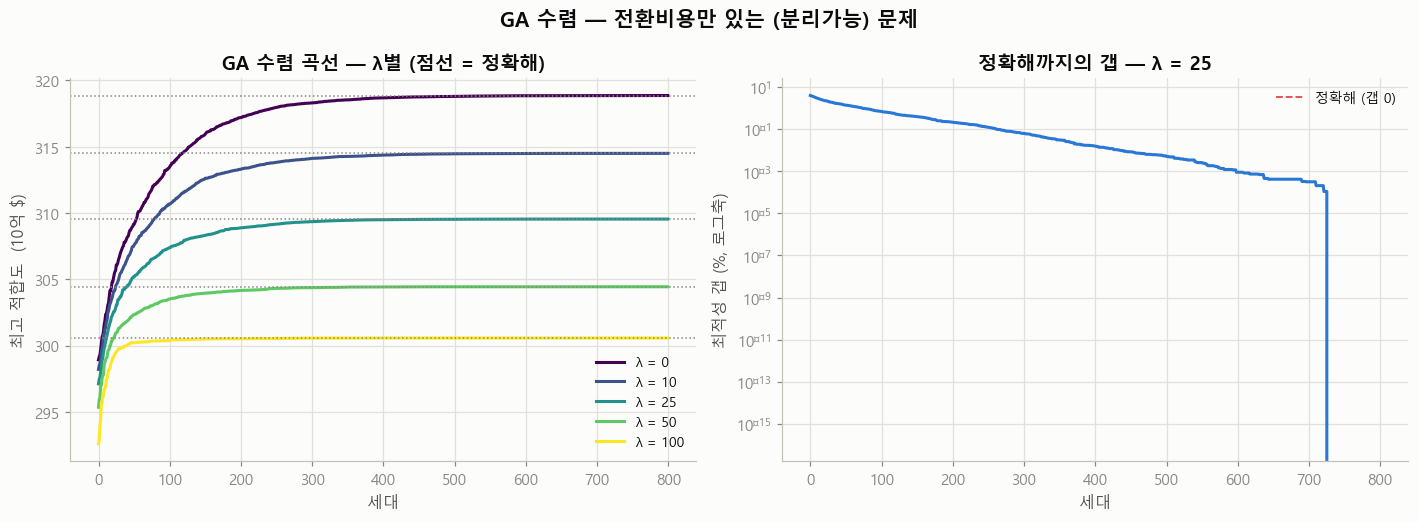

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

ax = axes[0]
for i, lam in enumerate(LAM_CHECK):
    r = ga_runs[lam]
    ax.plot(r['history'] / 1e9, color=plt.cm.viridis(i / max(1, len(LAM_CHECK) - 1)),
            label='λ = %g' % lam)
    f_ex = fitness(exact_optimum(WARM, lam), WARM, lam)
    ax.axhline(f_ex / 1e9, color=MUTED, ls=':', lw=1)
ax.set_xlabel('세대'); ax.set_ylabel('최고 적합도  (10억 $)')
ax.set_title('GA 수렴 곡선 — λ별 (점선 = 정확해)')
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
lam0 = 25.0
r = ga_runs[lam0]
f_ex = fitness(exact_optimum(WARM, lam0), WARM, lam0)
gap_hist = 100 * (f_ex - r['history']) / abs(f_ex)
ax.plot(gap_hist, color=BLUE)
ax.axhline(0, color=RED, ls='--', lw=1.2, label='정확해 (갭 0)')
ax.set_yscale('log')
ax.set_xlabel('세대'); ax.set_ylabel('최적성 갭 (%, 로그축)')
ax.set_title('정확해까지의 갭 — λ = %g' % lam0)
ax.legend(frameon=False, fontsize=9)

fig.suptitle('GA 수렴 — 전환비용만 있는 (분리가능) 문제', fontsize=13.5, fontweight='semibold')
fig.tight_layout()
save(fig, 'fig27_ga_convergence.png'); plt.show()

## 6. 전환비용 트레이드오프 — λ 스윕 (개요 §5 Phase 6 · H6 · **핵심 그림**)

λ 를 0 부터 크게까지 스윕한다. 각 λ 에서 GA 를 돌리고, 정확해도 함께 구해 GA 를 채점한다.

- x축: 작물을 바꾼 **면적 비율** (또는 카운티 비율)
- y축: 온난화 손실 **회복률 (%)**
- 곡선의 **무릎(knee)** = "적은 변화로 큰 회복" 스윗스팟

무릎은 원점–끝점을 잇는 직선에서 **수직 거리가 최대인 점**으로 정의한다(표준 knee/elbow 규칙).

In [10]:
LAMBDAS = np.concatenate([[0.0], np.geomspace(1.0, 400.0, 17)])
rows = []

for lam in LAMBDAS:
    z_ex = exact_optimum(WARM, lam)
    r = run_ga(WARM, lam, seed=SEED)
    z_ga = r['best']
    for tag, z in [('exact', z_ex), ('GA', z_ga)]:
        rows.append(dict(**{
            'lambda': lam, 'method': tag,
            'total_value': total_value(z, WARM),
            'fitness': fitness(z, WARM, lam),
            'n_switch': int((z != XBAR).sum()),
            'pct_counties': 100 * float((z != XBAR).mean()),
            'pct_area': 100 * switch_area(z) / A_TOT,
            'recovery_pct': recovery_pct(z),
            'corn_area_pct': 100 * A[z == 0].sum() / A_TOT,
        }))

sweep = pd.DataFrame(rows)
sweep.to_csv(RES / 'lambda_sweep_tradeoff.csv', index=False)
print('saved:', RES / 'lambda_sweep_tradeoff.csv')

sw_ga = sweep[sweep.method == 'GA'].reset_index(drop=True)
sw_ex = sweep[sweep.method == 'exact'].reset_index(drop=True)

# ── 무릎 찾기 (정확해 곡선 기준) ────────────────────────────────────────────
px, py = sw_ex.pct_area.to_numpy(), sw_ex.recovery_pct.to_numpy()
o = np.argsort(px); px, py = px[o], py[o]
p0, p1 = np.array([px[0], py[0]]), np.array([px[-1], py[-1]])
d = p1 - p0; d = d / np.linalg.norm(d)
pts = np.column_stack([px, py]) - p0
dist = np.abs(pts[:, 0] * d[1] - pts[:, 1] * d[0])
ki = int(dist.argmax())
KNEE = dict(pct_area=px[ki], recovery=py[ki])
KNEE_LAM = float(sw_ex.sort_values('pct_area')['lambda'].to_numpy()[ki])
print('\n무릎(knee): λ = %.1f $/ac · 전환면적 %.1f%% · 회복률 %.1f%%'
      % (KNEE_LAM, KNEE['pct_area'], KNEE['recovery']))

print('\nλ 스윕 (정확해 기준, 일부)')
cols = ['lambda', 'pct_counties', 'pct_area', 'recovery_pct', 'corn_area_pct']
print(sw_ex.iloc[::3][cols].to_string(index=False, float_format='%.1f'))

saved: ..\outputs\results\lambda_sweep_tradeoff.csv

무릎(knee): λ = 42.3 $/ac · 전환면적 11.2% · 회복률 16.0%

λ 스윕 (정확해 기준, 일부)
 lambda  pct_counties  pct_area  recovery_pct  corn_area_pct
    0.0          29.7      29.9          22.6           36.2
    2.1          28.9      29.4          22.6           36.3
    6.5          26.5      26.8          22.4           36.8
   20.0          19.5      19.6          20.7           37.3
   61.5           7.2       7.4          12.4           41.3
  189.1           0.1       0.1           0.5           47.1


### 그림 2 — 전환비용 트레이드오프 곡선

saved: ..\outputs\figures\fig28_tradeoff_curve.png


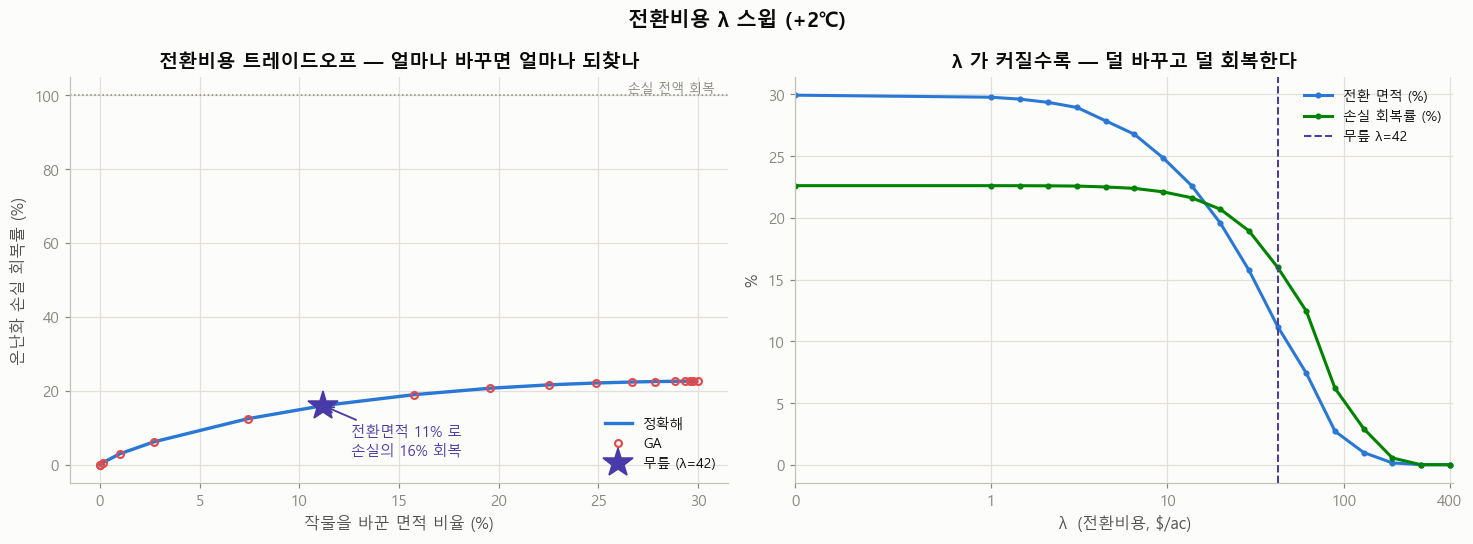

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0))

ax = axes[0]
ax.plot(sw_ex.pct_area, sw_ex.recovery_pct, '-', color=BLUE, lw=2.2, label='정확해', zorder=3)
ax.plot(sw_ga.pct_area, sw_ga.recovery_pct, 'o', color=RED, ms=4.5, mfc='none', mew=1.4,
        label='GA', zorder=4)
ax.plot(KNEE['pct_area'], KNEE['recovery'], '*', color=VIOLET, ms=20, zorder=5,
        label='무릎 (λ=%.0f)' % KNEE_LAM)
ax.annotate('전환면적 %.0f%% 로\n손실의 %.0f%% 회복' % (KNEE['pct_area'], KNEE['recovery']),
            xy=(KNEE['pct_area'], KNEE['recovery']), xytext=(18, -32), textcoords='offset points',
            fontsize=9.5, color=VIOLET,
            arrowprops=dict(arrowstyle='->', color=VIOLET, lw=1.2))
ax.axhline(100, color=MUTED, ls=':', lw=1)
ax.text(0.98, 100, ' 손실 전액 회복', ha='right', va='bottom', fontsize=8.5, color=MUTED,
        transform=ax.get_yaxis_transform())
ax.set_xlabel('작물을 바꾼 면적 비율 (%)'); ax.set_ylabel('온난화 손실 회복률 (%)')
ax.set_title('전환비용 트레이드오프 — 얼마나 바꾸면 얼마나 되찾나')
ax.legend(frameon=False, fontsize=9, loc='lower right')

ax = axes[1]
ax.plot(sw_ex['lambda'], sw_ex.pct_area, '-o', color=BLUE, ms=3, label='전환 면적 (%)')
ax.plot(sw_ex['lambda'], sw_ex.recovery_pct, '-o', color=GREEN, ms=3, label='손실 회복률 (%)')
ax.axvline(KNEE_LAM, color=VIOLET, ls='--', lw=1.3, label='무릎 λ=%.0f' % KNEE_LAM)
ax.set_xscale('symlog', linthresh=1)
ax.set_xlim(0, 420)                                    # λ ≥ 0 — 음수 구간 눈금 제거
ax.set_xticks([0, 1, 10, 100, 400])
ax.set_xticklabels(['0', '1', '10', '100', '400'])
ax.set_xlabel('λ  (전환비용, $/ac)'); ax.set_ylabel('%')
ax.set_title('λ 가 커질수록 — 덜 바꾸고 덜 회복한다')
ax.legend(frameon=False, fontsize=9)

fig.suptitle('전환비용 λ 스윕 (+%.0f℃)' % DELTA_T, fontsize=13.5, fontweight='semibold')
fig.tight_layout()
save(fig, 'fig28_tradeoff_curve.png'); plt.show()

## 7. 최소 수요 제약 — **GA 가 진짜로 필요해지는 지점** (개요 §6-(선택))

$$\sum_c A_c \cdot \mathbb{1}[z_c = \text{corn}] \;\geq\; D_{corn}$$

식량안보상 옥수수 면적을 일정 수준 이상 유지한다. 이 제약은 **카운티를 서로 묶는다** — 더 이상 분리되지 않는다.

이제 문제는 *"목적함수 손실을 최소화하면서 옥수수 면적 하한을 채우는"* **커버링 배낭(covering knapsack)** 이 되고,
카운티별 argmax 로는 풀리지 않는다. 여기서 GA 가 제 역할을 한다.

**GA 채점 방법**: 배낭의 **LP 완화 상한**(손실/면적 비율로 정렬 후 마지막 항목만 분수 허용)을 계산한다.
이건 정수해의 진짜 상한이므로 GA 의 **증명 가능한 최적성 갭**을 준다.

**제약 처리**: 수리(repair) 연산자 — 옥수수 면적이 부족하면 손실/면적 비가 가장 낮은 대두 카운티부터 옥수수로 뒤집는다.

In [12]:
def make_constrained(s, lam, D_corn):
    """최소 옥수수 면적 제약 D_corn 에 대한 feasible / repair / LP상한."""

    def corn_area(Z):
        return ((Z == 0) * A[None, :]).sum(axis=1)

    def feasible(Z):
        return corn_area(Z) >= D_corn - 1e-6

    # 대두→옥수수 전환의 단위면적당 목적함수 손실 (작을수록 싸게 옥수수를 늘림)
    adj = VAL[s] - lam * (np.arange(2)[None, :] != XBAR[:, None])    # (N,2)
    loss_per_ac = adj[:, 1] - adj[:, 0]        # 대두 선택 대비 옥수수 선택의 손실 ($/ac)
    order = np.argsort(loss_per_ac)            # 싼 것부터

    Ao = A[order]

    def repair(Z, rng):
        """옥수수 면적이 D_corn 에 못 미치면, 손실이 싼 대두 카운티부터 옥수수로 뒤집는다. (벡터화)"""
        need = D_corn - corn_area(Z)                 # (P,) 부족분
        if not (need > 0).any():
            return Z
        Zo   = Z[:, order]                           # 손실이 싼 순서로 재배열
        soy  = (Zo == 1)
        csum = np.cumsum(soy * Ao[None, :], axis=1)  # 여기까지 뒤집으면 얻는 누적 면적
        prev = csum - soy * Ao[None, :]              # 이 카운티 직전까지의 누적
        flip = soy & (prev < np.maximum(need, 0)[:, None])   # 부족분을 채울 때까지만
        Zo   = np.where(flip, 0, Zo).astype(np.int8)
        Z    = Z.copy()
        Z[:, order] = Zo
        return Z

    def lp_upper_bound():
        """분수 허용 커버링 배낭 → 정수 최적해의 상한."""
        z0 = adj.argmax(axis=1)                # 무제약 최적
        gap = D_corn - A[z0 == 0].sum()
        base = float((A * adj[np.arange(N), z0]).sum())
        if gap <= 0:
            return base, True                  # 제약 비구속
        cand = [c for c in order if z0[c] == 1]     # 뒤집을 수 있는 대두 카운티
        loss, filled = 0.0, 0.0
        for c in cand:
            if filled >= gap:
                break
            take = min(A[c], gap - filled)     # ★ 분수 허용
            loss += take * max(loss_per_ac[c], 0.0)
            filled += take
        return base - loss, False

    return feasible, repair, lp_upper_bound

# ── 여러 D 수준에서 GA ─────────────────────────────────────────────────────
LAM_C = KNEE_LAM                    # 무릎 λ 에서 식량안보 제약의 비용을 본다
z_unc = exact_optimum(WARM, LAM_C)
CORN_UNC = A[z_unc == 0].sum() / A_TOT
CORN_XBAR = A[XBAR == 0].sum() / A_TOT
print('λ=%.0f 무제약 최적해의 옥수수 면적 비율: %.1f%%  (현재 배분 %.1f%%)'
      % (LAM_C, 100 * CORN_UNC, 100 * CORN_XBAR))

D_FRACS = [0.20, 0.30, 0.40, 0.50, 0.60]
rows = [];  con_runs = {}
for df in D_FRACS:
    D = df * A_TOT
    feas, rep, lub = make_constrained(WARM, LAM_C, D)
    ub, slack = lub()
    r = run_ga(WARM, LAM_C, seed=SEED,
               feasible=feas, repair=rep, init=rep(z_unc[None, :], None)[0])
    con_runs[df] = r
    z = r['best']
    ok = bool(feas(z[None, :])[0])
    rows.append(dict(**{
        'D_corn(면적%)': 100 * df, '제약 비구속': slack,
        'GA F': r['best_fit'], 'LP 상한': ub,
        '갭(%)': 100 * (ub - r['best_fit']) / abs(ub),
        '실현가능': ok,
        '옥수수면적(%)': 100 * A[z == 0].sum() / A_TOT,
        '전환면적(%)': 100 * switch_area(z) / A_TOT,
        '회복률(%)': recovery_pct(z),
        'GA 초': r['seconds'],
    }))

constrained = pd.DataFrame(rows)
print('\n최소 수요 제약 (λ=%.0f, +%.0f℃)' % (LAM_C, DELTA_T))
print(constrained.to_string(index=False, float_format='%.4g'))
constrained.to_csv(RES / 'min_demand_constraint.csv', index=False)
print('\nsaved:', RES / 'min_demand_constraint.csv')

λ=42 무제약 최적해의 옥수수 면적 비율: 39.4%  (현재 배분 47.3%)



최소 수요 제약 (λ=42, +2℃)
 D_corn(면적%)  제약 비구속      GA F     LP 상한      갭(%)  실현가능  옥수수면적(%)  전환면적(%)  회복률(%)  GA 초
          20    True 3.057e+11 3.057e+11         0  True     39.44     11.2   15.99 30.82
          30    True 3.057e+11 3.057e+11         0  True     39.44     11.2   15.99 20.18
          40   False 3.057e+11 3.057e+11 0.0002112  True        40    11.13   15.92 43.61
          50   False 3.028e+11 3.028e+11  0.000709  True        50    10.68   12.24 54.99
          60   False 2.958e+11 2.958e+11 0.0003708  True        60     16.2   8.315 79.62

saved: ..\outputs\results\min_demand_constraint.csv


## 8. 기준선 비교 — 무조정 vs Greedy vs GA (개요 H7)

In [13]:
Z_GA_KNEE = run_ga(WARM, KNEE_LAM, seed=SEED)['best']
Z_EX_KNEE = exact_optimum(WARM, KNEE_LAM)

D_SEC = 0.40 * A_TOT
feas_s, rep_s, lub_s = make_constrained(WARM, KNEE_LAM, D_SEC)
Z_GA_CON = run_ga(WARM, KNEE_LAM, seed=SEED,
                  feasible=feas_s, repair=rep_s,
                  init=rep_s(exact_optimum(WARM, KNEE_LAM)[None, :], None)[0])['best']

SCEN = [
    ('무조정 (현재 배분 유지)',      Z_NOADAPT, 0.0),
    ('Greedy (전환비용 무시)',        Z_GREEDY,  0.0),
    ('GA (λ=%.0f, 무릎)' % KNEE_LAM,  Z_GA_KNEE, KNEE_LAM),
    ('GA + 옥수수 40% 하한',          Z_GA_CON,  KNEE_LAM),
]
rows = []
for name, z, lam in SCEN:
    rows.append(dict(**{
        '방법': name,
        '총순이익($)': total_value(z, WARM),
        '전환비용($)': lam * switch_area(z),
        '순 목적함수($)': fitness(z, WARM, lam),
        '전환 카운티': int((z != XBAR).sum()),
        '전환 카운티(%)': 100 * float((z != XBAR).mean()),
        '전환 면적(%)': 100 * switch_area(z) / A_TOT,
        '손실 회복률(%)': recovery_pct(z),
        '옥수수 면적(%)': 100 * A[z == 0].sum() / A_TOT,
    }))
baselines = pd.DataFrame(rows)
print('기준선 비교 (+%.0f℃, 온난화 손실 = $%.3e)' % (DELTA_T, LOSS))
print(baselines.to_string(index=False, float_format='%.4g'))
baselines.to_csv(RES / 'baseline_comparison.csv', index=False)
print('\nsaved:', RES / 'baseline_comparison.csv')

기준선 비교 (+2℃, 온난화 손실 = $8.574e+10)
              방법   총순이익($)   전환비용($)  순 목적함수($)  전환 카운티  전환 카운티(%)  전환 면적(%)  손실 회복률(%)  옥수수 면적(%)
  무조정 (현재 배분 유지) 2.995e+11         0  2.995e+11       0          0         0          0      47.28
Greedy (전환비용 무시) 3.189e+11         0  3.189e+11     637      29.74     29.94      22.61      36.18
   GA (λ=42, 무릎) 3.132e+11 7.496e+09  3.057e+11     238      11.11      11.2      15.99      39.44
 GA + 옥수수 40% 하한 3.131e+11 7.451e+09  3.057e+11     239      11.16     11.13      15.92         40

saved: ..\outputs\results\baseline_comparison.csv


### 그림 3 — 손실 회복 막대

saved: ..\outputs\figures\fig29_loss_recovery.png


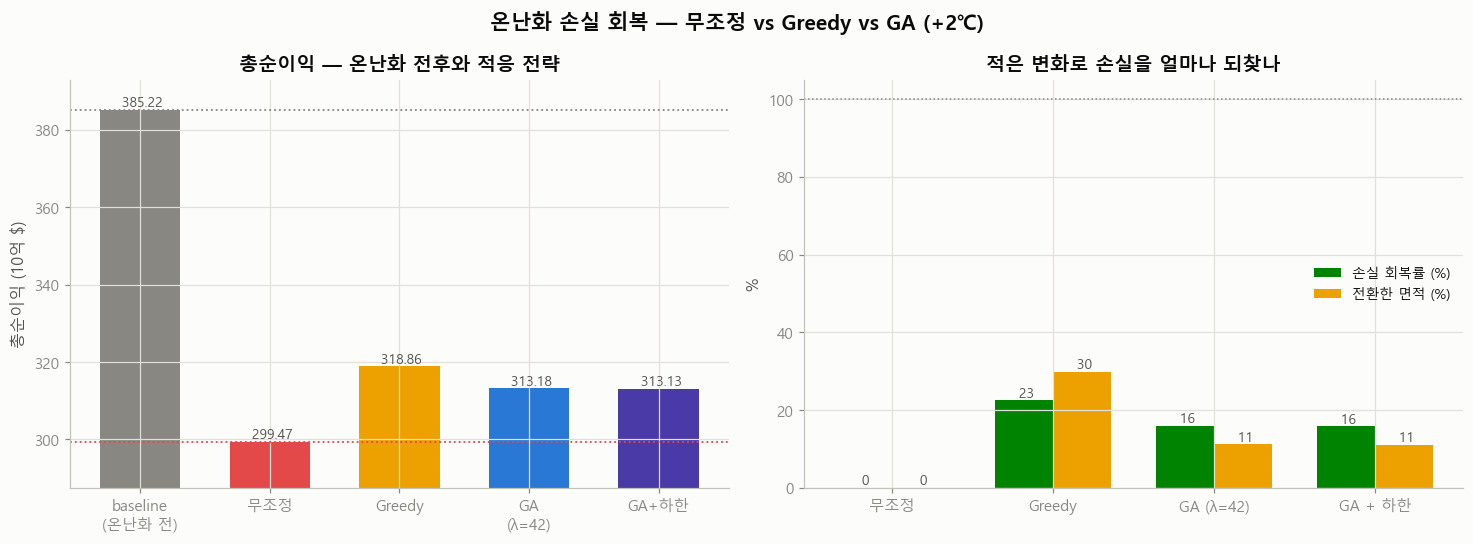

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0))

# (a) 총순이익 수준 비교
ax = axes[0]
names = ['baseline\n(온난화 전)', '무조정', 'Greedy', 'GA\n(λ=%.0f)' % KNEE_LAM, 'GA+하한']
vals = [V_BASE_NOADAPT, V_WARM_NOADAPT, total_value(Z_GREEDY, WARM),
        total_value(Z_GA_KNEE, WARM), total_value(Z_GA_CON, WARM)]
cols = [MUTED, RED, YELLOW, BLUE, VIOLET]
b = ax.bar(names, np.array(vals) / 1e9, color=cols, width=0.62)
ax.axhline(V_BASE_NOADAPT / 1e9, color=MUTED, ls=':', lw=1.2)
ax.axhline(V_WARM_NOADAPT / 1e9, color=RED, ls=':', lw=1.2)
for r, v in zip(b, vals):
    ax.text(r.get_x() + r.get_width() / 2, v / 1e9, ' %.2f' % (v / 1e9),
            ha='center', va='bottom', fontsize=9, color=SECOND)
ax.set_ylabel('총순이익 (10억 $)')
ax.set_ylim(min(vals) / 1e9 * 0.96, max(vals) / 1e9 * 1.02)
ax.set_title('총순이익 — 온난화 전후와 적응 전략')

# (b) 회복률 + 전환량
ax = axes[1]
meth = ['무조정', 'Greedy', 'GA (λ=%.0f)' % KNEE_LAM, 'GA + 하한']
rec  = [0.0, recovery_pct(Z_GREEDY), recovery_pct(Z_GA_KNEE), recovery_pct(Z_GA_CON)]
sar  = [0.0, 100 * switch_area(Z_GREEDY) / A_TOT, 100 * switch_area(Z_GA_KNEE) / A_TOT,
        100 * switch_area(Z_GA_CON) / A_TOT]
x = np.arange(len(meth)); w = 0.36
b1 = ax.bar(x - w / 2, rec, w, color=GREEN, label='손실 회복률 (%)')
b2 = ax.bar(x + w / 2, sar, w, color=YELLOW, label='전환한 면적 (%)')
for bb in (b1, b2):
    for r in bb:
        ax.text(r.get_x() + r.get_width() / 2, r.get_height(), ' %.0f' % r.get_height(),
                ha='center', va='bottom', fontsize=9, color=SECOND)
ax.axhline(100, color=MUTED, ls=':', lw=1)
ax.set_xticks(x); ax.set_xticklabels(meth)
ax.set_ylabel('%')
ax.set_title('적은 변화로 손실을 얼마나 되찾나')
ax.legend(frameon=False, fontsize=9)

fig.suptitle('온난화 손실 회복 — 무조정 vs Greedy vs GA (+%.0f℃)' % DELTA_T,
             fontsize=13.5, fontweight='semibold')
fig.tight_layout()
save(fig, 'fig29_loss_recovery.png'); plt.show()

## 9. 작물 배치 지도 (개요 §5 Phase 8 · H8 재배 벨트 북상)

`cntymap` 셰이프파일 + FIPS(`stco`) 결합. 05 와 동일하게 `pyshp` 사용(투영좌표계 그대로).

saved: ..\outputs\figures\fig30_crop_map.png


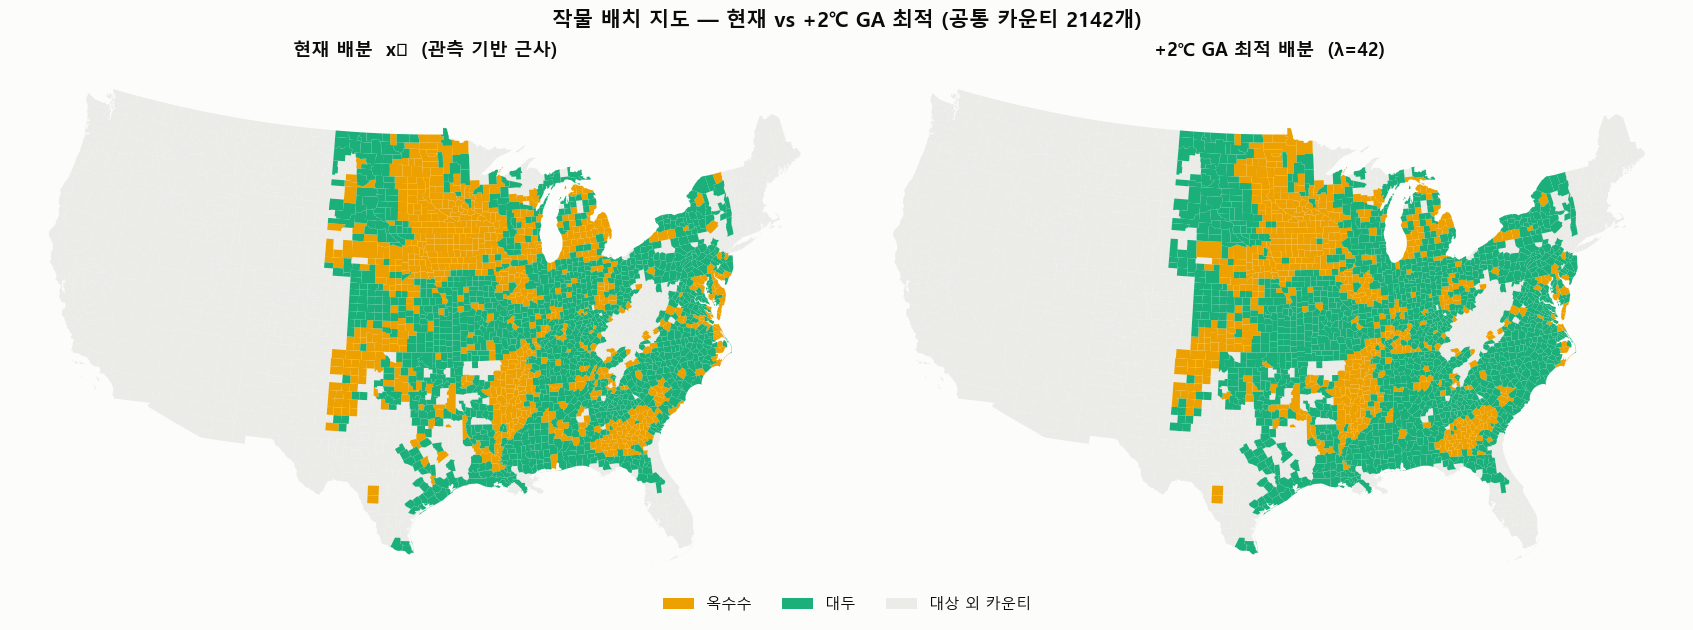

In [15]:
import shapefile
sf = shapefile.Reader(str(RAW / 'cntymap' / 'cntymap'), encoding='latin-1')   # DBF 는 latin-1
recs, shapes = sf.records(), sf.shapes()
stco_of = [r['stco'] for r in recs]
IDX = {s: i for i, s in enumerate(COUNTIES)}

def county_polys(value_of):
    """value_of: dict stco -> 값. (대상 폴리곤, 값, 비대상 폴리곤) 반환."""
    pin, vin, pout = [], [], []
    for i, sh in enumerate(shapes):
        pts = np.asarray(sh.points); parts = list(sh.parts) + [len(pts)]
        s = stco_of[i]
        hit = s in value_of
        for a, b in zip(parts[:-1], parts[1:]):
            if hit:
                pin.append(pts[a:b]); vin.append(value_of[s])
            else:
                pout.append(pts[a:b])
    return pin, np.array(vin), pout

def draw_alloc(ax, z, title):
    vo = {int(s): int(z[IDX[s]]) for s in COUNTIES}
    pin, vin, pout = county_polys(vo)
    ax.add_collection(PolyCollection(pout, facecolors='#ebebe8', edgecolors='none', zorder=1))
    for j, col in [(0, CORN_C), (1, SOY_C)]:
        sel = [p for p, v in zip(pin, vin) if v == j]
        if sel:
            ax.add_collection(PolyCollection(sel, facecolors=col, edgecolors='none', zorder=2))
    ax.autoscale_view(); ax.set_aspect('equal'); ax.axis('off'); ax.grid(False)
    ax.set_title(title, fontsize=12)

fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.6))
draw_alloc(axes[0], XBAR, '현재 배분  x̄  (관측 기반 근사)')
draw_alloc(axes[1], Z_GA_KNEE, '+%.0f℃ GA 최적 배분  (λ=%.0f)' % (DELTA_T, KNEE_LAM))
handles = [Patch(facecolor=CORN_C, label='옥수수'), Patch(facecolor=SOY_C, label='대두'),
           Patch(facecolor='#ebebe8', label='대상 외 카운티')]
fig.legend(handles=handles, loc='lower center', ncol=3, frameon=False, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle('작물 배치 지도 — 현재 vs +%.0f℃ GA 최적 (공통 카운티 %d개)' % (DELTA_T, N),
             fontsize=13.5, fontweight='semibold')
fig.tight_layout()
save(fig, 'fig30_crop_map.png'); plt.show()

### 그림 4 — 어느 카운티가 바뀌는가 (전환 지도)

saved: ..\outputs\figures\fig31_switch_map.png


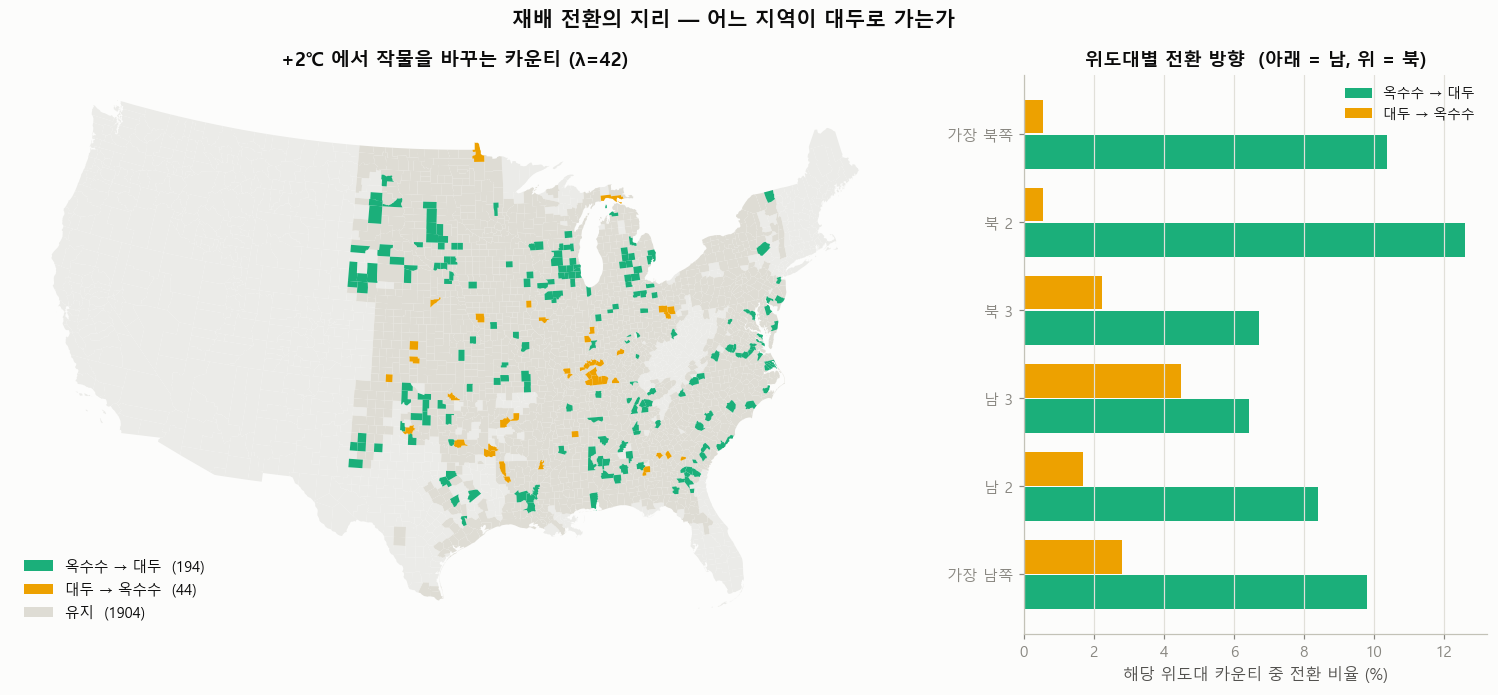

 위도대      중심위도  옥수수to대두  대두to옥수수   n
   0 1002904.5      9.8      2.8 357
   1 1358371.4      8.4      1.7 357
   2 1625327.0      6.4      4.5 357
   3 1863812.0      6.7      2.2 357
   4 2100421.7     12.6      0.6 357
   5 2463444.0     10.4      0.6 357


In [16]:
# 0 = 유지, 1 = 옥수수→대두, 2 = 대두→옥수수
chg = np.zeros(N, dtype=int)
chg[(XBAR == 0) & (Z_GA_KNEE == 1)] = 1
chg[(XBAR == 1) & (Z_GA_KNEE == 0)] = 2
n_c2s, n_s2c = int((chg == 1).sum()), int((chg == 2).sum())

fig = plt.figure(figsize=(14, 6.4))
gs = fig.add_gridspec(1, 2, width_ratios=[2.05, 1])

ax = fig.add_subplot(gs[0, 0])
vo = {int(s): int(chg[IDX[s]]) for s in COUNTIES}
pin, vin, pout = county_polys(vo)
ax.add_collection(PolyCollection(pout, facecolors='#ebebe8', edgecolors='none', zorder=1))
for j, col in [(0, '#dedcd4'), (1, SOY_C), (2, CORN_C)]:
    sel = [p for p, v in zip(pin, vin) if v == j]
    if sel:
        ax.add_collection(PolyCollection(sel, facecolors=col, edgecolors='none', zorder=2))
ax.autoscale_view(); ax.set_aspect('equal'); ax.axis('off'); ax.grid(False)
ax.set_title('+%.0f℃ 에서 작물을 바꾸는 카운티 (λ=%.0f)' % (DELTA_T, KNEE_LAM), fontsize=12.5)
handles = [Patch(facecolor=SOY_C, label='옥수수 → 대두  (%d)' % n_c2s),
           Patch(facecolor=CORN_C, label='대두 → 옥수수  (%d)' % n_s2c),
           Patch(facecolor='#dedcd4', label='유지  (%d)' % int((chg == 0).sum()))]
ax.legend(handles=handles, loc='lower left', frameon=False, fontsize=9.5)

# 위도(주 FIPS 대리)별 전환 — 벨트 북상 확인
ax = fig.add_subplot(gs[0, 1])
lat = np.array([np.asarray(shapes[i].points)[:, 1].mean() for i in range(len(shapes))])
lat_of = {}
for i, s in enumerate(stco_of):
    lat_of.setdefault(s, lat[i])
la = np.array([lat_of.get(int(s), np.nan) for s in COUNTIES])
ok = np.isfinite(la)
q = pd.qcut(la[ok], 6, labels=False)
bins = []
for b in range(6):
    m = np.zeros(N, bool); m[np.where(ok)[0][q == b]] = True
    bins.append(dict(위도대=b, 중심위도=la[m].mean(),
                     옥수수to대두=100 * (chg[m] == 1).mean(),
                     대두to옥수수=100 * (chg[m] == 2).mean(),
                     n=int(m.sum())))
bdf = pd.DataFrame(bins).sort_values('중심위도')
yy = np.arange(len(bdf))
ax.barh(yy - 0.2, bdf.옥수수to대두, 0.38, color=SOY_C, label='옥수수 → 대두')
ax.barh(yy + 0.2, bdf.대두to옥수수, 0.38, color=CORN_C, label='대두 → 옥수수')
ax.set_yticks(yy)
ax.set_yticklabels(['가장 남쪽', '남 2', '남 3', '북 3', '북 2', '가장 북쪽'])
ax.set_xlabel('해당 위도대 카운티 중 전환 비율 (%)')
ax.set_title('위도대별 전환 방향  (아래 = 남, 위 = 북)', fontsize=12)
ax.legend(frameon=False, fontsize=9)
ax.grid(axis='y', alpha=0)

fig.suptitle('재배 전환의 지리 — 어느 지역이 대두로 가는가', fontsize=13.5, fontweight='semibold')
fig.tight_layout()
save(fig, 'fig31_switch_map.png'); plt.show()

print(bdf.to_string(index=False, float_format='%.1f'))

## 10. 결과 저장

In [17]:
out = pd.DataFrame({
    'stco': COUNTIES,
    'A_c': A,
    'y_hat_corn_base':  y_hat[BASE]['corn'],
    'y_hat_soy_base':   y_hat[BASE]['soybean'],
    'y_hat_corn_warm':  y_hat[WARM]['corn'],
    'y_hat_soy_warm':   y_hat[WARM]['soybean'],
    'v_corn_base':      VAL[BASE][:, 0],
    'v_soy_base':       VAL[BASE][:, 1],
    'v_corn_warm':      VAL[WARM][:, 0],
    'v_soy_warm':       VAL[WARM][:, 1],
    'x_bar':            XBAR,
    'z_greedy':         Z_GREEDY,
    'z_ga_knee':        Z_GA_KNEE,
    'z_exact_knee':     Z_EX_KNEE,
    'z_ga_constrained': Z_GA_CON,
    'switch_ga':        (Z_GA_KNEE != XBAR).astype(np.int8),
})
out.to_parquet(PROC / 'optimization_results.parquet', index=False)
print('saved:', PROC / 'optimization_results.parquet', out.shape)

meta = {
    'purpose': '06 단작 조합 최적화 (GA) 결과 — 개요 §6-(2)+(3)',
    'n_counties': int(N),
    'scenario': {'baseline': 0.0, WARM: DELTA_T},
    'objective': 'sum_c A_c * v[c,z_c] - lambda * sum_{z_c != xbar_c} A_c',
    'value_unit': '$/ac 순이익 = PRICE*y_hat - OPCOST',
    'PRICE_usd_per_bu': PRICE,
    'OPCOST_usd_per_ac': OPCOST,
    'lambda_knee': KNEE_LAM,
    'seed': SEED,
    'ga': {'pop_size': GA_POP, 'n_gen': GA_GEN, 'tournament_k': 3,
           'crossover': 'uniform (p=0.9)', 'mutation': 'bit-flip (p=1/N)', 'n_elite': 2},
    'x_bar_rule': ('2011-2015 관측 수확량에 순이익 규칙 적용 → 높은 쪽이 주작물. '
                   '최근 5년 결측 시 1981-2015 전체 평균으로 대체.'),
    'headline': {
        'warming_loss_usd': float(LOSS),
        'warming_loss_pct': float(100 * LOSS / V_BASE_NOADAPT),
        'ga_recovery_pct': float(recovery_pct(Z_GA_KNEE)),
        'ga_switch_area_pct': float(100 * switch_area(Z_GA_KNEE) / A_TOT),
        'ga_switch_counties': int((Z_GA_KNEE != XBAR).sum()),
        'greedy_recovery_pct': float(recovery_pct(Z_GREEDY)),
        'greedy_switch_area_pct': float(100 * switch_area(Z_GREEDY) / A_TOT),
    },
    'warnings': [
        'bu/ac 목적함수는 degenerate (모든 카운티에서 옥수수 우위) — 순이익 $/ac 로 단위화함.',
        '가격/변동비는 외부 상수(USDA ERS 수준). 데이터에 없는 가정이므로 민감도 확인 필요.',
        'x_bar 는 재배 면적이 아니라 관측 수확량 기반 근사 (개요 §9 한계).',
        '전환비용만 있는 문제는 분리가능 → 정확해가 O(N). GA 의 필요성은 최소수요 제약에서 생긴다.',
        'ppt 는 시나리오 간 고정 (05 상속). 온난화의 강수 변화 미반영.',
    ],
}
json.dump(meta, open(PROC / 'optimization_columns.json', 'w', encoding='utf-8'),
          ensure_ascii=False, indent=2)
print('saved:', PROC / 'optimization_columns.json')

saved: ..\data\processed\optimization_results.parquet (2142, 16)
saved: ..\data\processed\optimization_columns.json


## 11. 부록 — 개요 명세(bu/ac) 그대로 돌리면 어떻게 되는가

§2-1 의 주장을 코드로 확인한다. 목적계수를 `y_hat` (bu/ac) 로 두고 같은 GA 를 돌린다.

In [18]:
VAL_BU = {s: np.column_stack([y_hat[s]['corn'], y_hat[s]['soybean']]) for s in [BASE, WARM]}
_VAL_SAVE = VAL
VAL = VAL_BU                                   # 목적계수만 bu/ac 로 갈아끼움
try:
    rows = []
    for lam in [0.0, 5.0, 20.0]:
        z_ex = exact_optimum(WARM, lam)
        r = run_ga(WARM, lam, n_gen=300, seed=SEED)
        rows.append(dict(**{'lambda': lam,
                            '정확해: 옥수수 카운티': int((z_ex == 0).sum()),
                            '정확해: 대두 카운티':   int((z_ex == 1).sum()),
                            'GA: 옥수수 카운티':     int((r['best'] == 0).sum()),
                            'GA: 대두 카운티':       int((r['best'] == 1).sum()),
                            '전환 면적(%)': 100 * switch_area(z_ex) / A_TOT}))
    print('[개요 §6-(2) 명세 그대로 — 목적계수 = bu/ac]')
    print(pd.DataFrame(rows).to_string(index=False, float_format='%.1f'))
finally:
    VAL = _VAL_SAVE                            # 원복

print('\n  → λ=0 에서 정확해는 2,142개 카운티 전부 옥수수. 대두 0개.')
print('  → λ 를 올리면 그냥 현재 배분으로 되돌아갈 뿐, 중간에 의미 있는 트레이드오프가 없다.')
print('  → 부셸을 작물 간에 더하는 목적함수는 "무조건 옥수수"라는 자명한 답만 낸다.')
print('     이것이 §2-1 에서 순이익 $/ac 로 단위화한 이유다.')

[개요 §6-(2) 명세 그대로 — 목적계수 = bu/ac]
 lambda  정확해: 옥수수 카운티  정확해: 대두 카운티  GA: 옥수수 카운티  GA: 대두 카운티  전환 면적(%)
    0.0          2142            0         1880         262      52.7
    5.0          2142            0         1809         333      52.7
   20.0          2142            0         1784         358      52.7

  → λ=0 에서 정확해는 2,142개 카운티 전부 옥수수. 대두 0개.
  → λ 를 올리면 그냥 현재 배분으로 되돌아갈 뿐, 중간에 의미 있는 트레이드오프가 없다.
  → 부셸을 작물 간에 더하는 목적함수는 "무조건 옥수수"라는 자명한 답만 낸다.
     이것이 §2-1 에서 순이익 $/ac 로 단위화한 이유다.


## 12. 요약

In [19]:
sw_pct_area = 100 * switch_area(Z_GA_KNEE) / A_TOT
sw_pct_cty  = 100 * float((Z_GA_KNEE != XBAR).mean())
rec_ga      = recovery_pct(Z_GA_KNEE)
rec_gr      = recovery_pct(Z_GREEDY)
gr_pct_area = 100 * switch_area(Z_GREEDY) / A_TOT
V_BASE_OPT  = total_value(exact_optimum(BASE, 0.0), BASE)

print('=' * 78)
print(' 06 · 단작 조합 최적화 (GA) — 요약'.center(78))
print('=' * 78)
print("""
[1] 온난화 손실 (무조정)
    baseline 총순이익      $ {vb:,.0f}
    +{dt:.0f}℃ 무조정 총순이익   $ {vw:,.0f}
    손실                   $ {loss:,.0f}   ({lp:.1f}%)

[2] GA 재배치가 회복한 양  (λ={kl:.0f} $/ac, 트레이드오프 곡선의 무릎)
    손실 회복률            {rg:.1f}%
    작물을 바꾼 카운티      {nc:d} / {N:d}  ({pc:.1f}%)
    작물을 바꾼 면적        {pa:.1f}%
    → "면적의 {pa:.0f}% 만 바꿔서 온난화 손실의 {rg:.0f}% 를 되찾는다"

[3] GA vs Greedy
    Greedy(전환비용 무시)  회복 {rgr:.1f}%  ·  전환면적 {pgr:.1f}%
    GA   (전환비용 고려)   회복 {rg:.1f}%  ·  전환면적 {pa:.1f}%
    → Greedy 는 {ratio:.1f}배 더 많은 땅을 갈아엎고 {diff:.1f}%p 더 회복한다.
      전환비용을 넣으면 훨씬 적은 변화로 회복의 대부분을 가져온다 (H6 스윗스팟).

[4] 전환의 지리 (H8)
    옥수수 → 대두  {c2s:d} 카운티
    대두 → 옥수수  {s2c:d} 카운티
""".format(vb=V_BASE_NOADAPT, dt=DELTA_T, vw=V_WARM_NOADAPT, loss=LOSS,
           lp=100 * LOSS / V_BASE_NOADAPT, kl=KNEE_LAM, rg=rec_ga,
           nc=int((Z_GA_KNEE != XBAR).sum()), N=N, pc=sw_pct_cty, pa=sw_pct_area,
           rgr=rec_gr, pgr=gr_pct_area,
           ratio=gr_pct_area / max(sw_pct_area, 1e-9), diff=rec_gr - rec_ga,
           c2s=n_c2s, s2c=n_s2c))

print('[5] GA vs 정확해 (H5)')
print('    전환비용만 있는 문제는 분리가능 → 정확해가 O(N) 에 나온다.')
print('    GA 최적성 갭: %.4f%% ~ %.4f%%  (λ 0~100), 유전자 일치 %.1f~%.1f%%'
      % (ga_vs_exact['갭(%)'].min(), ga_vs_exact['갭(%)'].max(),
         ga_vs_exact['유전자 일치(%)'].min(), ga_vs_exact['유전자 일치(%)'].max()))
print('    무릎 λ 에서 GA 해 == 정확해 : %s'
      % bool((Z_GA_KNEE == Z_EX_KNEE).all()))
print('    → GA 는 정확해에 도달한다. 하지만 이 문제에서 GA 를 쓸 "이유"는 없다 (정확해가 더 빠르다).')
print('    최소수요 제약(옥수수 면적 하한)을 넣으면 카운티가 서로 묶여 분리가능성이 깨지고,')
print('    거기서부터 GA 가 제 역할을 한다 (LP 상한 대비 갭 %.4f%%).'
      % constrained.loc[constrained['D_corn(면적%)'] == 40.0, '갭(%)'].iloc[0])

print('\n[6] 주의 — H8("재배 벨트 북상")은 이 분석으로 판정할 수 없다')
gain = int((y_hat[WARM]['corn'] > y_hat[BASE]['corn']).sum())
print('    +%.0f℃ 로 옥수수 수확량이 오히려 늘어나는 카운티: %d / %d (%.0f%%)'
      % (DELTA_T, gain, N, 100 * gain / N))
print('    위도대별 옥수수→대두 전환율: %s'
      % ' · '.join('%.1f%%' % v for v in bdf.옥수수to대두))
print('      (남 → 북 순서. 단조 증가도 감소도 아니다 — 뚜렷한 남북 기울기가 없다.)')
print('    → 북상도 남하도 데이터가 지지하지 않는다. 우리 피처셋에 생육기간·서리일수가 없어')
print('      북상을 만드는 채널 자체가 모델에 없기 때문이다. §13-7 참조.')
print('=' * 78)

                           06 · 단작 조합 최적화 (GA) — 요약                           

[1] 온난화 손실 (무조정)
    baseline 총순이익      $ 385,217,152,938
    +2℃ 무조정 총순이익   $ 299,474,284,141
    손실                   $ 85,742,868,797   (22.3%)

[2] GA 재배치가 회복한 양  (λ=42 $/ac, 트레이드오프 곡선의 무릎)
    손실 회복률            16.0%
    작물을 바꾼 카운티      238 / 2142  (11.1%)
    작물을 바꾼 면적        11.2%
    → "면적의 11% 만 바꿔서 온난화 손실의 16% 를 되찾는다"

[3] GA vs Greedy
    Greedy(전환비용 무시)  회복 22.6%  ·  전환면적 29.9%
    GA   (전환비용 고려)   회복 16.0%  ·  전환면적 11.2%
    → Greedy 는 2.7배 더 많은 땅을 갈아엎고 6.6%p 더 회복한다.
      전환비용을 넣으면 훨씬 적은 변화로 회복의 대부분을 가져온다 (H6 스윗스팟).

[4] 전환의 지리 (H8)
    옥수수 → 대두  194 카운티
    대두 → 옥수수  44 카운티

[5] GA vs 정확해 (H5)
    전환비용만 있는 문제는 분리가능 → 정확해가 O(N) 에 나온다.
    GA 최적성 갭: 0.0000% ~ 0.0001%  (λ 0~100), 유전자 일치 99.8~100.0%
    무릎 λ 에서 GA 해 == 정확해 : True
    → GA 는 정확해에 도달한다. 하지만 이 문제에서 GA 를 쓸 "이유"는 없다 (정확해가 더 빠르다).
    최소수요 제약(옥수수 면적 하한)을 넣으면 카운티가 서로 묶여 분리가능성이 깨지고,
    거기서부터 GA 가 제 역할을 한다 (LP 상한 대비 갭 0.0002%).

[6] 주의 —

## 13. 이상한 점 · 판단이 필요한 부분

**1. 목적함수의 단위 — 가장 큰 판단 지점 (§2-1, §11)**
개요 §6 의 $\sum_k y\_hat[c,k] \cdot A_c \cdot z[c,k]$ 는 작물 간 부셸을 그냥 더하는데, 이건 성립하지 않는다.
그대로 쓰면 2,142개 카운티 **전부** 옥수수가 되어(대두 우위 카운티 0개) 최적화 자체가 무의미해진다.
순이익 \$/ac 로 단위화해 문제를 살렸다. **다만 가격(\$4.50/bu, \$10.50/bu)과 변동비(\$400/ac, \$205/ac)는
데이터에 없는 외부 가정이다.** 결과의 방향은 이 숫자들에 의존한다 — 특히 **옥수수 변동비가 대두의 약 2배**라는
비대칭이 대두 전환을 만든다. 발표 전에 이 값들의 출처를 USDA ERS 로 확정하고 민감도 분석을 붙이는 게 좋다.

**2. `y_hat` 이 아니라 `v` 를 최대화하면 "총생산 최대화"가 아니다**
개요의 표현은 "총생산 최대화"지만 실제로 최대화하는 건 **총 순이익**이다. 발표에서 이 전환을 명시해야 한다.
(총 부셸을 최대화하는 문제는 §11 이 보여주듯 답이 "전부 옥수수"로 정해져 있다.)

**3. 이 문제에 GA 가 필요한가 — 정직하게는 "아니오"**
전환비용만 있는 단작 문제는 카운티별로 분리되어 정확해가 $O(N)$ 에 나온다.
개요 §2 의 서사("카운티가 많아지면 조합이 폭발 → MILP 느려짐 → 메타휴리스틱 필요")는 **이 정식화에서는 성립하지 않는다.**
조합 폭발은 결정변수가 많다고 생기는 게 아니라 **제약이 변수를 묶을 때** 생긴다.
→ 그래서 최소수요 제약(§7)을 넣었고, 거기서는 분리가능성이 깨져 GA 가 실제로 필요하다.
**발표에서 이 점을 약점이 아니라 통찰로 제시하는 걸 권한다** — "왜 GA 가 필요한가"를 제대로 이해했다는 증거다.
(SA 를 추가할 때도 같은 논지가 적용된다: 제약 있는 버전에서 비교해야 의미가 있다.)

**4. 회복률이 100% 를 넘을 수 있다**
회복률은 *무조정 대비* 이득을 *온난화 손실* 로 나눈 값이다. 그런데 현재 배분 $\bar{x}$ 는 baseline 에서도
모델 기준 최적이 아니다 — 즉 재배치 이득에는 **"온난화 적응"** 과 **"원래 있던 비효율 제거"** 가 섞여 있다.
`V_BASE_OPT` 를 함께 계산해 두었으니, 발표에서 이 둘을 분리해 말하는 게 정직하다.

**5. `x̄` 는 재배 면적이 아니다**
`yielddata.csv` 에 작물별 재배 면적이 없어 관측 수확량의 순이익 비교로 주작물을 근사했다(개요 §9 한계).
실제 미국은 옥수수-대두 **윤작**이 표준이라 "카운티가 작물 하나를 고른다"는 단작 가정 자체가 단순화다.
결과는 "이 카운티의 주력을 어느 쪽으로 기울일까"로 읽어야 하며, "밭을 통째로 바꾼다"로 읽으면 안 된다.

**6. 05 에서 상속된 한계**
`ppt` 가 시나리오 간 고정(온난화의 강수 변화 미반영), 균일 +2℃ 이동 가정, `year` 고정(트리 외삽 불가).
`y_hat` 의 예측오차(옥수수 RMSE 20 bu/ac ≈ 순이익 \$90/ac)가 무릎 λ(~수십 \$/ac)와 **같은 자릿수**라
**카운티 단위 전환 권고는 노이즈에 취약하다.** 집계 수준(지역/위도대) 결론이 훨씬 견고하다.

**7. ⚠ H8("재배 벨트 북상")은 이 분석으로 판정할 수 없다 — 발표 전에 반드시 짚어야 할 부분**
개요 H8 은 온난화 시 옥수수 벨트가 **북상**할 것으로 예상했다. 결과는 그걸 지지하지도, 반증하지도 않는다.
위도대별 옥수수→대두 전환율에 **뚜렷한 남북 기울기가 없다**(§9 표: 대략 6~13% 사이를 오갈 뿐 단조적이지 않다).
그림 fig31 의 전환 카운티들도 특정 위도에 몰려 있지 않고 벨트 전역에 흩어져 있다.

원인은 **모델 구조**에 있다. 우리 수확량 모델의 온도 채널은 **29℃ 초과 고온 피해**뿐이다.
실제 농학에서 옥수수 벨트를 북으로 밀어 올리는 힘은 **북부의 생육기간 연장·서리일수 감소·적산온도 확보**인데,
그 변수들이 **피처셋에 아예 없다**(온도 노출 분포 + 강수 + 토양뿐). 그래서 온난화가 북부 옥수수에 주는
가장 중요한 *이득* 채널이 모델에 존재하지 않는다. (그럼에도 +2℃ 에서 옥수수 수확량이 **늘어나는** 카운티가
373개(17%) 나오긴 한다 — 저온 구간 노출이 유익 구간으로 옮겨간 효과다. 다만 이건 생육기간 연장과는 다른 채널이다.)

**즉 H8 을 검정할 수 있는 모델이 애초에 아니다.** 발표에서 "북상이 관측되지 않았다"고 말하면
*모델이 북상을 부정했다*는 오해를 준다. 정직한 서술은 이렇다:

> *"우리 모델은 고온 피해 채널만 담고 있어 재배 벨트의 북상 여부를 판정할 수 없다.
> 모델이 말할 수 있는 것은 고온 피해에 대한 **상대적 취약성**뿐이고, 그 기준에서 옥수수가 대두보다 취약하다."*

H8 을 제대로 다루려면 생육기간 길이·서리일수·적산온도 같은 피처가 필요하다 → **향후 과제**로 넘기는 게 맞다.
(H8 은 03/04 의 피처 설계에서 이미 결정된 한계이지, 06 최적화의 문제가 아니다.)